## Relatório PDI - Processamento Morfológico de Imagens

## Lab 7

**Aluno(s)**: Gabriella Rodrigues, Nayara Amaral, Veronica Isobe \
**Data de publicação**: 07/04/2026 \
**Data de realização dos experimentos**: 05/04/2026

# 1. Introdução
O Laboratório 7 tem como objetivo introduzir e explorar os principais conceitos de processamento morfológico aplicado a imagens binárias, enfatizando operações fundamentais como erosão, dilatação, abertura e fechamento. A proposta envolve tanto a implementação prática dessas técnicas utilizando ferramentas como Python, OpenCV e bibliotecas específicas, quanto a análise dos efeitos dessas operações sobre diferentes tipos de imagens, incluindo imagens reais e capturadas por webcam. Além disso, o experimento busca desenvolver a capacidade de interpretação dos resultados, avaliando aspectos como filtragem de ruídos, conectividade de objetos e extração de contornos, bem como compreender a influência de parâmetros como o tamanho e o formato do elemento estruturante. Dessa forma, o laboratório integra teoria e prática, promovendo uma compreensão aprofundada das aplicações do processamento morfológico no contexto de análise e manipulação de imagens digitais

# 2. Procedimentos experimentais

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [4]:
img = cv2.imread('foto.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

In [5]:
img_personagens = cv2.imread('foto_personagens.png')
img_personagens_gray = cv2.cvtColor(img_personagens, cv2.COLOR_RGBA2GRAY)

In [6]:
def exibir_imagens(imagens, titulos):
    """
    Exibe uma lista de imagens lado a lado usando matplotlib.
    """
    n = len(imagens)
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    if n == 1:
        axes = [axes]

    for ax, img, tit in zip(axes, imagens, titulos):
        ax.imshow(img, cmap='gray')
        ax.set_title(tit)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("Função útil para exibir imagens.")

Função útil para exibir imagens.


### 2.1 Operações de Erosão e Dilatação

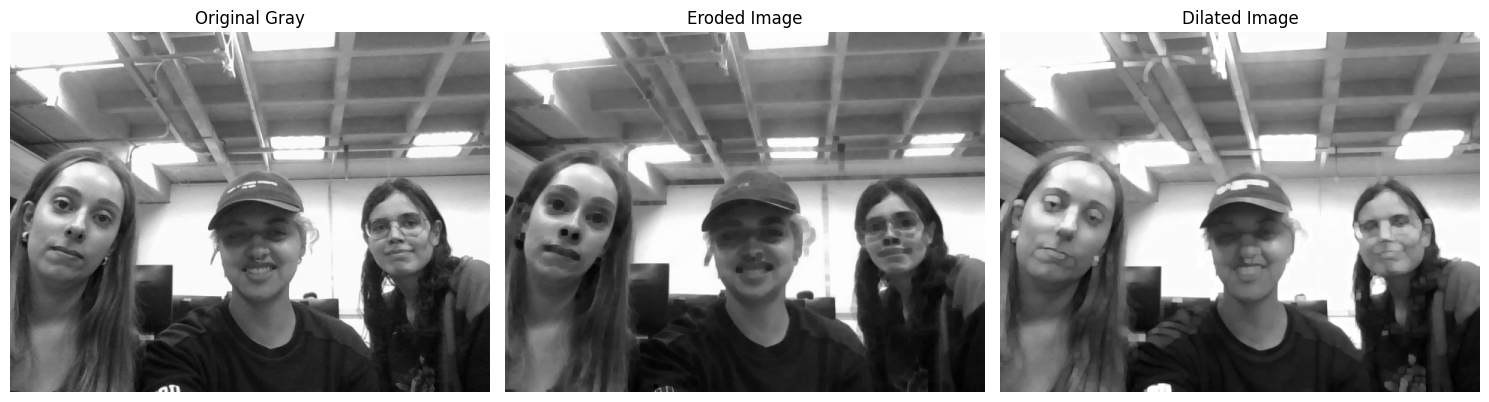

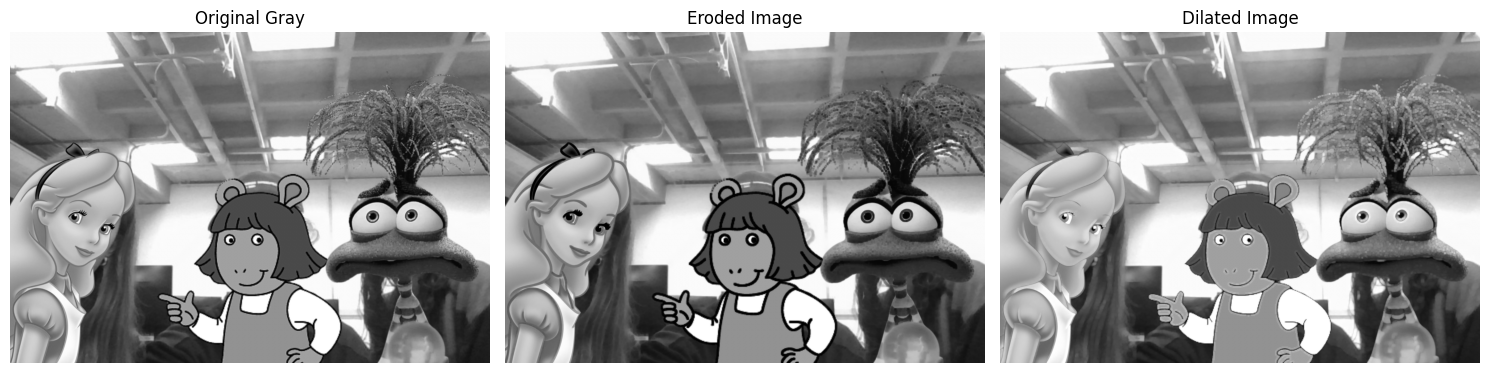

In [7]:
kernel = np.ones((5,5),np.uint8)

img_eroded = cv2.erode(img_gray, kernel, iterations = 1)
img_dilated = cv2.dilate(img_gray, kernel, iterations = 1)

# imagem avatares
img_eroded_personagens = cv2.erode(img_personagens_gray, kernel, iterations = 1)
img_dilated_personagens = cv2.dilate(img_personagens_gray, kernel, iterations = 1)

exibir_imagens([img_gray, img_eroded, img_dilated], ['Original Gray', 'Eroded Image', 'Dilated Image'])
exibir_imagens([img_personagens_gray, img_eroded_personagens, img_dilated_personagens], ['Original Gray', 'Eroded Image', 'Dilated Image'])

### 2.2 Operações de Abertura e Fechamento

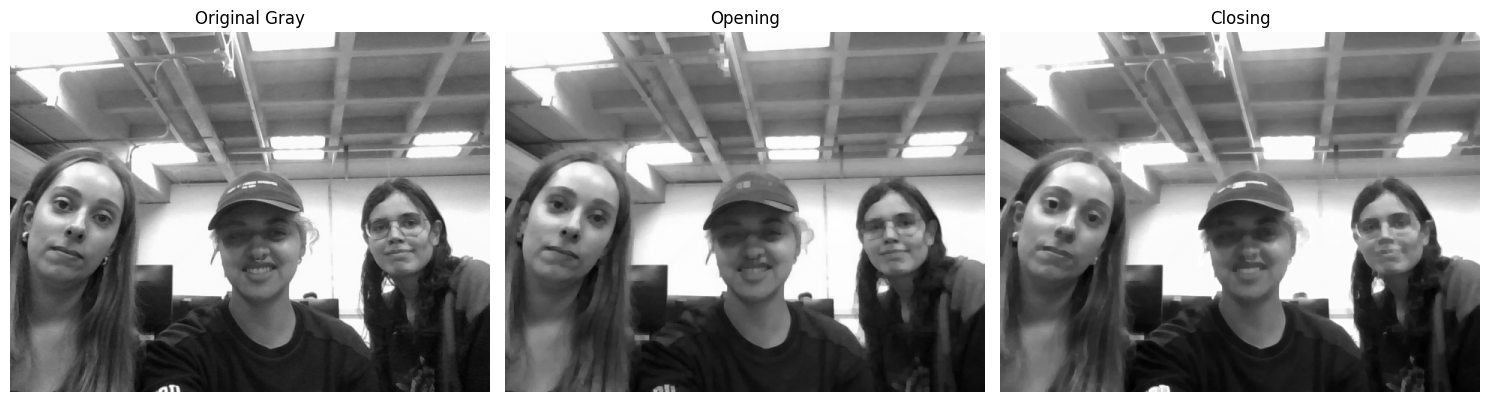

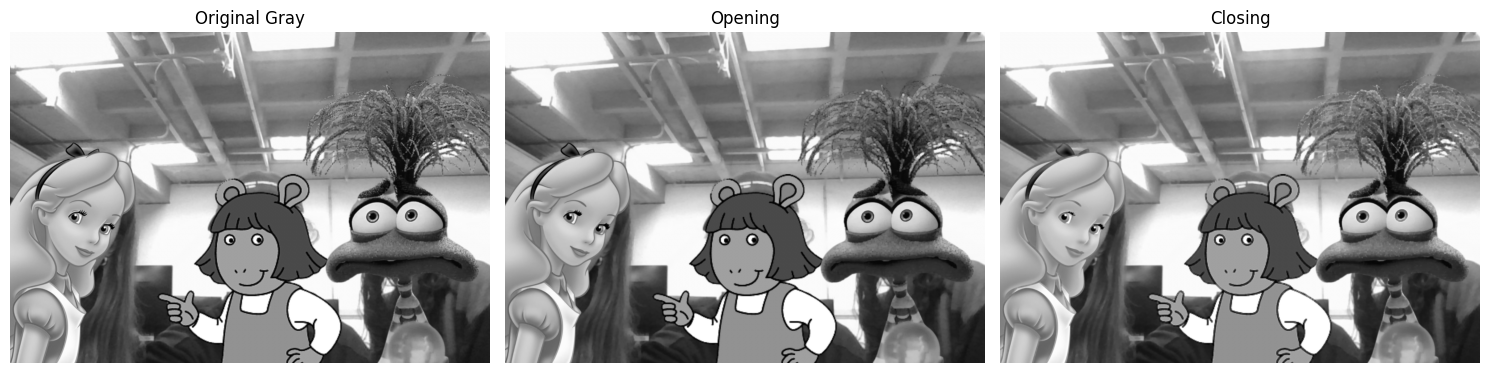

In [8]:
img_opening = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel)
img_closing = cv2.morphologyEx(img_gray, cv2.MORPH_CLOSE, kernel)

# imagem avatares
img_opening_personagens = cv2.morphologyEx(img_personagens_gray, cv2.MORPH_OPEN, kernel)
img_closing_personagens = cv2.morphologyEx(img_personagens_gray, cv2.MORPH_CLOSE, kernel)

exibir_imagens([img_gray, img_opening, img_closing], ['Original Gray', 'Opening', 'Closing'])
exibir_imagens([img_personagens_gray, img_opening_personagens, img_closing_personagens], ['Original Gray', 'Opening', 'Closing'])

### 2.3 Gravação webcam

In [ ]:
# 3.b

filterChoice = 1
limiar = 80
kernel_size = 3  # novo controle do kernel

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Erro ao acessar webcam")
    exit()

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = None
gravando = False

while True:
    ret, frame = cap.read()
    if not ret:
        print("Erro ao capturar frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if filterChoice == 1:
        t, frameWithFilter = cv2.threshold(
            gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        texto = f"Otsu (T={int(t)})"
    else:
        _, frameWithFilter = cv2.threshold(
            gray, limiar, 255, cv2.THRESH_BINARY
        )
        texto = f"Manual (T={int(limiar)})"

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    gradient = cv2.morphologyEx(frameWithFilter, cv2.MORPH_GRADIENT, kernel)

    # Converter para 3 canais
    gradient_bgr = cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR)

    # Combinar lado a lado
    combinado = np.hstack((frame, gradient_bgr))

    cv2.putText(combinado, texto, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

    cv2.putText(combinado, f"Kernel: {kernel_size}x{kernel_size}",
                (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2)

    cv2.putText(combinado,
                "s=trocar | w=gravar | +/- limiar | k/K kernel | q=sair",
                (10, 460),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 1)

    cv2.imshow("Original | Gradiente Morfologico", combinado)

    if gravando:
        out.write(combinado)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('s'):
        filterChoice = 2 if filterChoice == 1 else 1

    if key == ord('+'):
        limiar = min(255, limiar + 5)

    if key == ord('-'):
        limiar = max(0, limiar - 5)

    # 🔹 controle do kernel (novo)
    if key == ord('k'):
        kernel_size += 2
        print(f"Kernel: {kernel_size}")

    if key == ord('K') and kernel_size > 3:
        kernel_size -= 2
        print(f"Kernel: {kernel_size}")

    # 🔹 gravação
    if key == ord('w'):
        gravando = not gravando

        if gravando:
            print("Gravando...")
            out = cv2.VideoWriter(
                "gradiente_morfologico.avi",
                fourcc,
                20.0,
                (combinado.shape[1], combinado.shape[0])
            )
        else:
            print("Parou gravação")
            out.release()

    if key == ord('q'):
        break

# Finalização correta
cap.release()
if out is not None:
    out.release()
cv2.destroyAllWindows()

### 2.4 Aplicar efeitos na imagem do projeto

In [10]:
img_postura = cv2.imread('postura_incorreta.jpg')
img_postura_gray = cv2.cvtColor(img_postura, cv2.COLOR_RGBA2GRAY)

### Dilatação e Erosão

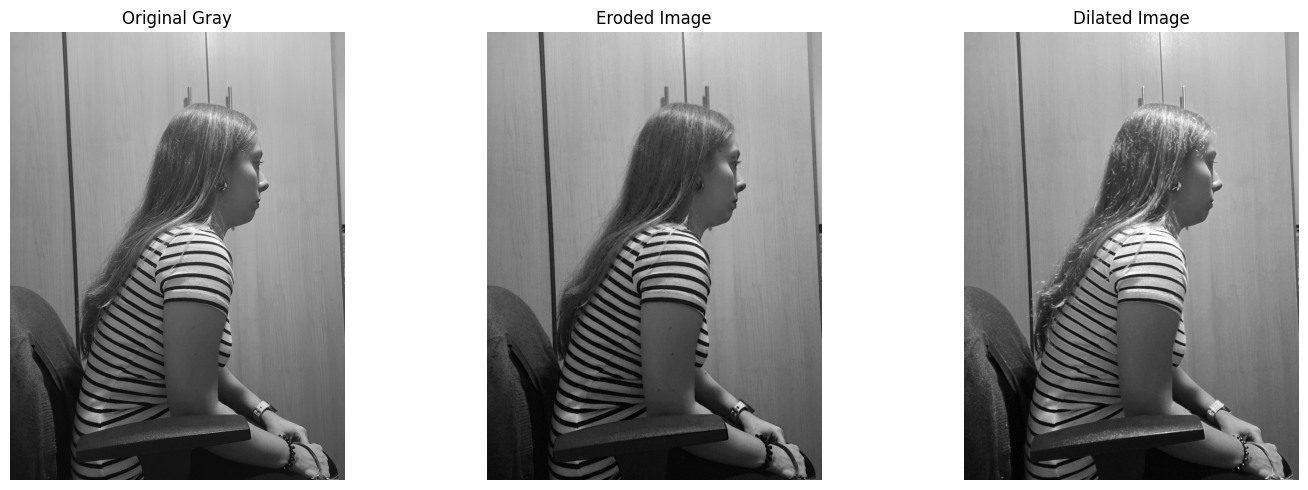

In [11]:
# 4.a

kernel = np.ones((5,5),np.uint8)

img_eroded = cv2.erode(img_postura_gray, kernel, iterations = 1)
img_dilated = cv2.dilate(img_postura_gray, kernel, iterations = 1)

exibir_imagens([img_postura_gray, img_eroded, img_dilated], ['Original Gray', 'Eroded Image', 'Dilated Image'])

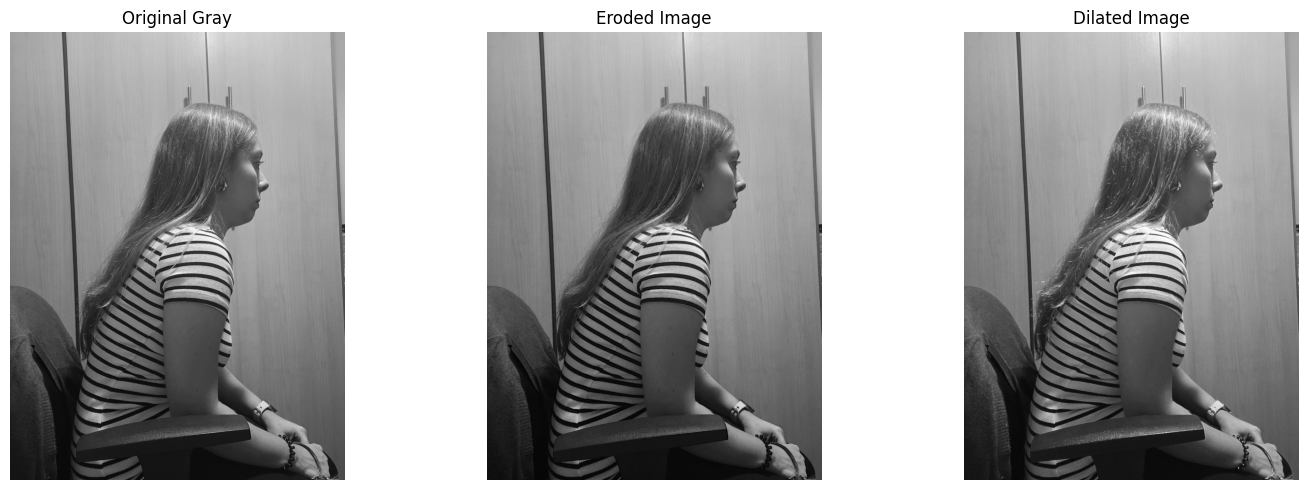

In [12]:
kernel = np.ones((3,3),np.uint8)

img_eroded = cv2.erode(img_postura_gray, kernel, iterations = 1)
img_dilated = cv2.dilate(img_postura_gray, kernel, iterations = 1)

exibir_imagens([img_postura_gray, img_eroded, img_dilated], ['Original Gray', 'Eroded Image', 'Dilated Image'])

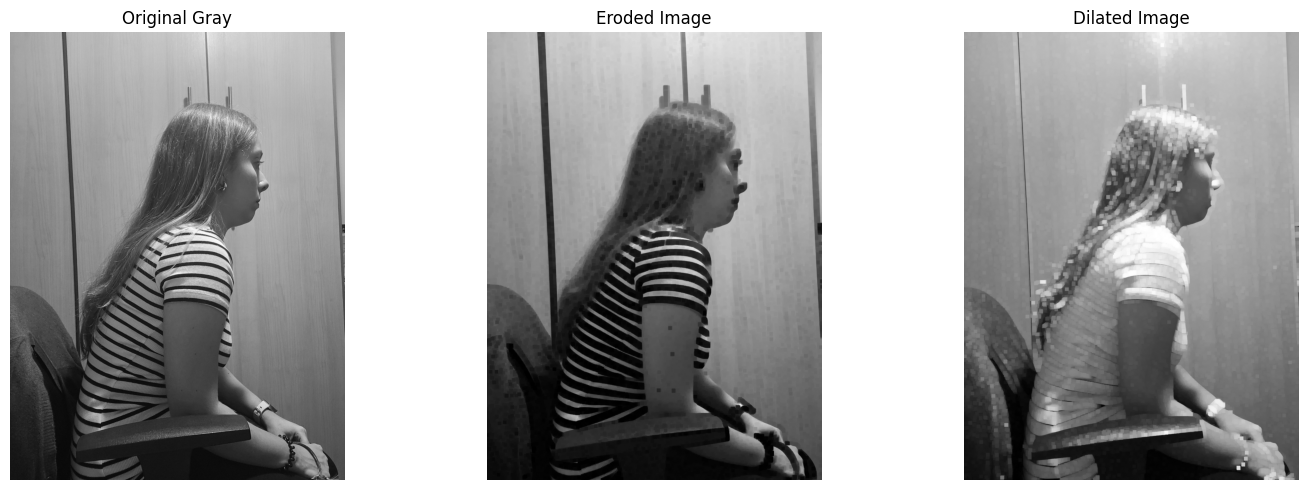

In [13]:
kernel = np.ones((21,21),np.uint8)

img_eroded = cv2.erode(img_postura_gray, kernel, iterations = 1)
img_dilated = cv2.dilate(img_postura_gray, kernel, iterations = 1)

exibir_imagens([img_postura_gray, img_eroded, img_dilated], ['Original Gray', 'Eroded Image', 'Dilated Image'])

### Abertura e fechamento

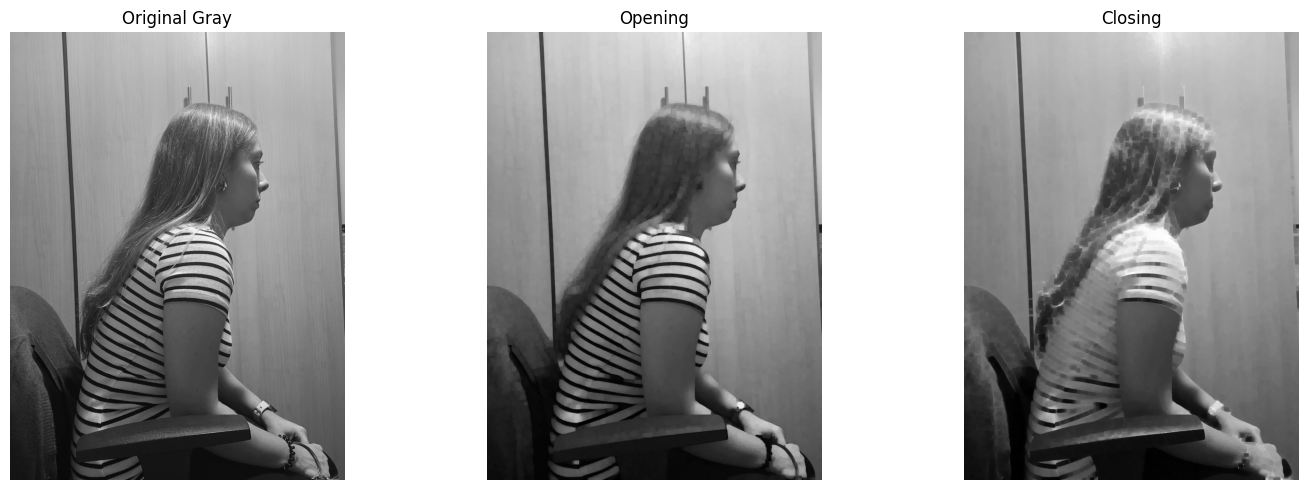

In [14]:
img_opening = cv2.morphologyEx(img_postura_gray, cv2.MORPH_OPEN, kernel)
img_closing = cv2.morphologyEx(img_postura_gray, cv2.MORPH_CLOSE, kernel)

exibir_imagens([img_postura_gray, img_opening, img_closing], ['Original Gray', 'Opening', 'Closing'])

# 3. Análise e discussão

**5.A)** . Erosão e Estrutura: Ao aplicar uma erosão em uma imagem binária que contém ruídos brancos (pontos isolados de 1 pixel) utilizando um kernel 3x3 de *uns*, o que acontece com esses ruídos? Explique o porquê baseando-se no funcionamento do operador

Ao aplicar uma erosão com um kernel 3x3x3 de "uns", os ruídos brancos serão removidos da imagem. Os ruídos brancos de 1 pixel são eliminados pois a erosão atua como um filtro que remove detalhes menores que o elemento estruturante utilizado. De acordo com o funcionamento do operador, um pixel de primeiro plano só é preservado se o kernel estiver completamente contido no objeto original. Como um ponto isolado de 1 pixel não comporta um elemento estruturante de 3 X 3, ele não satisfaz essa condição e é removido da imagem resultante.

**5.B)** Dilatação e Conectividade: Suponha que você tenha uma imagem de um texto digitalizado onde as letras estão levemente "quebradas" ou fragmentadas. Qual o efeito de aplicar uma dilatação com um elemento estruturante pequeno (ex: 3x3)? Existe algum efeito colateral indesejado se o kernel for grande demais

A dilatação com kernel pequeno preenche lacunas e une segmentos quebrados ao expandir os limites das formas, restaurando a conectividade das letras. O efeito colateral de um kernel excessivamente grande é o espessamento exagerado dos caracteres. Isso resulta na perda de definição, fusão de letras adjacentes e obstrução de espaços internos vazios, o que prejudica severamente a legibilidade do texto

**5.C)**  Extração de Contornos (Gradiente): A extração de fronteira pode ser feita
subtraindo a imagem erosionada da imagem original (A−(A⊖B)) .
 -- Prática: O que mudaria no contorno resultante se aumentássemos o tamanho do
elemento estruturante B de 3x3 para 11x11?

O contorno resultante tornaria-se significativamente mais espesso, uma vez que o aumento do elemento estruturante amplia a profundidade da erosão sobre o objeto original. Enquanto um kernel 3 X 3 remove apenas a camada mais externa de pixels, o de 11 X  11 elimina uma faixa muito mais larga das bordas. Assim, a subtração da imagem erosionada da original resulta em uma fronteira com espessura proporcional ao maior tamanho do elemento estruturante utilizado.

# 4. Conclusão

As atividades comprovaram a eficácia dos operadores morfológicos na filtragem de ruídos e no realce de estruturas em imagens binárias. A aplicação prática de erosão, dilatação, abertura e fechamento permitiu o controle preciso sobre a conectividade e os contornos dos objetos analisados. O uso da webcam para extração de fronteiras em tempo real validou a versatilidade dessas técnicas para segmentação e análise de formas, cumprindo integralmente os objetivos propostos para o laboratório.